In [4]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------- -------------------------- 3.9/11.3 MB 20.3 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.3 MB 20.5 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 19.3 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---- ----------------------------------- 3.9/37.4 MB 20.6 MB/s eta 0:00:02
   -------- ------------------------------- 8.4/37.4 MB 20.6 MB/s eta 0:00:02
   ------------- -------------------------- 12.8/37.4 MB 20.6 MB/s eta 0:00:02
   ------------------ --------------------- 17.0/37.4 MB 20.6 MB/s eta 0:00:01
   ----------------------- ---------------- 21.5/37.4 MB 20.6 MB/s eta 0:00:01
   --------------------------- ------------ 26.0/37.4 MB 20.6 MB/s eta 0:00:01
   -------------------------------- ------- 30.1/37.4 MB 20.6 MB/s eta 0:00:01
   ------------------------------------- -- 34.6/37.4 MB 20.6 MB/s eta 0:00:0

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
crsp = pd.read_csv("crsp.csv")
ff = pd.read_csv("ff.csv")

crsp.head()

,PERMNO,HdrCUSIP,Ticker,PERMCO,DlyCalDt,DlyPrc,DlyCap,DlyRet
0,16678,50104410,KR,21068,2020-01-02,28.66,22944823.42,-0.011383
1,16678,50104410,KR,21068,2020-01-03,28.70,22976846.90,0.001396
2,16678,50104410,KR,21068,2020-01-06,28.80,23056905.60,0.003484
3,16678,50104410,KR,21068,2020-01-07,28.59,22888782.33,-0.007292
4,16678,50104410,KR,21068,2020-01-08,28.42,22752682.54,-0.005946


In [17]:
ff.head()

,date,mktrf,smb,hml,rf
0,2021-01-04,-0.0141,0.0020,0.0057,0.0
1,2021-01-05,0.0086,0.0122,0.0050,0.0
2,2021-01-06,0.0079,0.0214,0.0394,0.0
3,2021-01-07,0.0176,0.0032,-0.0081,0.0
4,2021-01-08,0.0051,-0.0075,-0.0138,0.0


In [37]:
# turn the date columns into proper dates
crsp["date"] = pd.to_datetime(crsp["DlyCalDt"])
ff["date"] = pd.to_datetime(ff["date"])

# quick check of which companies we have
crsp["Ticker"].unique()

<StringArray>
['KR', 'TGT', 'WMT', 'COST']
Length: 4, dtype: str

In [19]:
# one column of returns per company
rets = crsp.pivot(index="date", columns="Ticker", values="DlyRet")

# put the returns and factors side by side, matched on date
data = pd.merge(rets, ff, on="date")
data = data.set_index("date").dropna()

data.head()

,COST,KR,TGT,WMT,mktrf,smb,hml,rf
date,,,,,,,,
2021-01-04,0.008944,0.011650,0.006231,0.016511,-0.0141,0.0020,0.0057,0.0
2021-01-05,-0.011601,-0.007158,0.015425,-0.005323,0.0086,0.0122,0.0050,0.0
2021-01-06,-0.015223,0.009718,0.047403,0.006244,0.0079,0.0214,0.0394,0.0
2021-01-07,-0.005675,-0.012108,0.011539,-0.000068,0.0176,0.0032,-0.0081,0.0
2021-01-08,0.005490,-0.005971,0.013082,-0.000136,0.0051,-0.0075,-0.0138,0.0


In [20]:
# check the sample period
print(data.index.min(), data.index.max(), len(data))

2021-01-04 00:00:00 2025-12-31 00:00:00 1255


In [38]:
tickers = ["WMT", "COST", "TGT", "KR"]

# Market return = market excess return + risk-free rate
data["MKT"] = data["mktrf"] + data["rf"]
all_rets = data[tickers + ["MKT"]]

summary = pd.DataFrame({
    "Mean daily return": all_rets.mean(),
    "Annualised return": all_rets.mean() * 252,
    "Annualised volatility": all_rets.std() * np.sqrt(252),
    "Total 5-year return": (1 + all_rets).prod() - 1,
})
print(summary.round(4))

      Mean daily return  Annualised return  Annualised volatility  \
WMT              0.0008             0.2044                 0.2088   
COST             0.0008             0.2028                 0.2251   
TGT             -0.0001            -0.0271                 0.3514   
KR               0.0008             0.1935                 0.2704   
MKT              0.0006             0.1407                 0.1773   

      Total 5-year return  
WMT                1.4814  
COST               1.4178  
TGT               -0.3631  
KR                 1.1878  
MKT                0.8633  


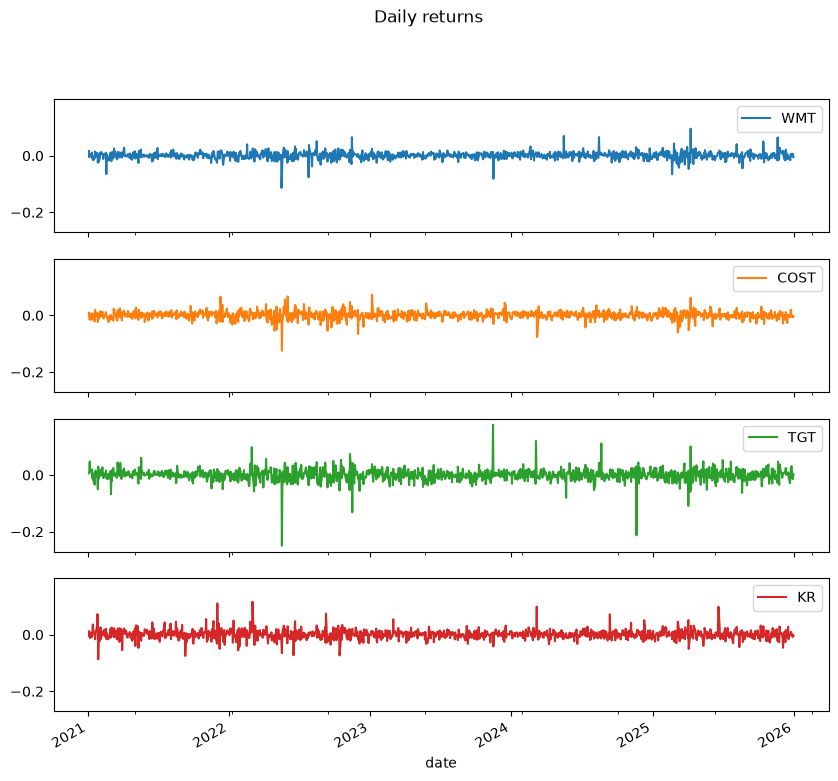

In [40]:
data[tickers].plot(subplots=True, figsize=(10, 9), sharey=True, title="Daily returns")
plt.savefig("fig1_daily_returns.png")
plt.show()

         WMT    COST     TGT      KR     MKT
date                                        
2021  0.0197  0.5181  0.3292  0.4540  0.2384
2022 -0.0047 -0.1906 -0.3427  0.0044 -0.1996
2023  0.1289  0.4897 -0.0136  0.0499  0.2690
2024  0.7398  0.3962 -0.0216  0.3690  0.2489
2025  0.2449 -0.0540 -0.2447  0.0423  0.1859


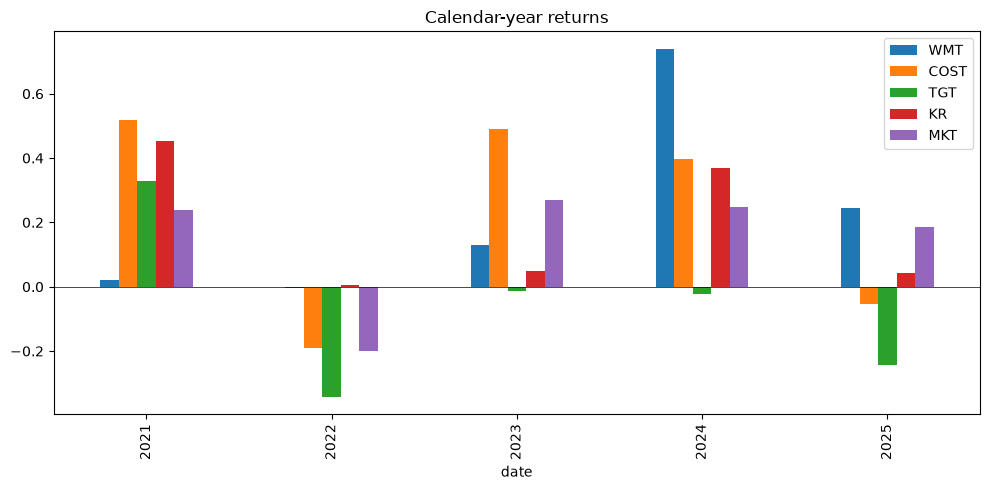

In [10]:
annual = (1 + all_rets).groupby(all_rets.index.year).prod() - 1
print(annual.round(4))

annual.plot(kind="bar", figsize=(10, 5), title="Calendar-year returns")
plt.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("fig2_annual_returns.png", dpi=200)
plt.show()

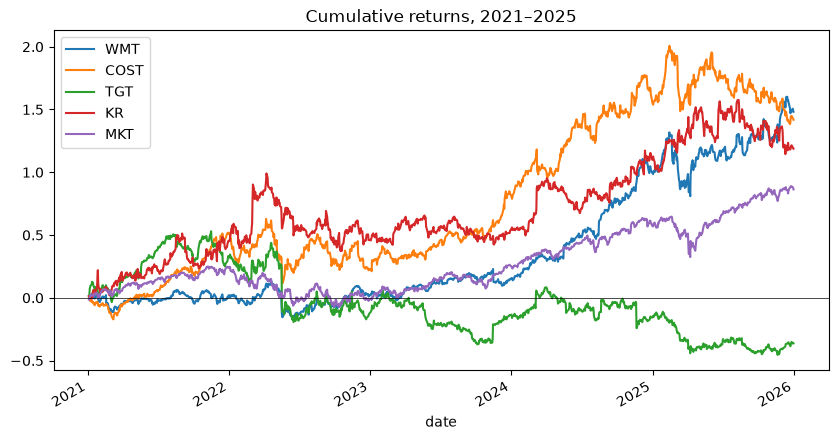

In [24]:
cum = (1 + all_rets).cumprod() - 1

cum.plot(figsize=(10, 5), title="Cumulative returns, 2021–2025")
plt.axhline(0, color="black", linewidth=0.5)
plt.savefig("fig3_cumulative_returns.png")
plt.show()

In [34]:
capm_results = {}

for t in tickers:
    y = data[t] - data["rf"]               # excess stock return
    X = sm.add_constant(data[["mktrf"]])   # market excess return + intercept
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    capm_results[t] = {
        "Alpha (daily)": model.params["const"],
        "Alpha (annualised)": model.params["const"] * 252,
        "Alpha t-stat": model.tvalues["const"],
        "Alpha p-value": model.pvalues["const"],
        "Beta": model.params["mktrf"],
        "R-squared": model.rsquared,
    }

capm_table = pd.DataFrame(capm_results).T
print(capm_table.round(4))

      Alpha (daily)  Alpha (annualised)  Alpha t-stat  Alpha p-value    Beta  \
WMT          0.0005              0.1260        1.4622         0.1437  0.4229   
COST         0.0004              0.0927        1.0939         0.2740  0.7164   
TGT         -0.0006             -0.1629       -1.2147         0.2245  0.9547   
KR           0.0006              0.1465        1.2953         0.1952  0.1323   

      R-squared  
WMT      0.1289  
COST     0.3181  
TGT      0.2318  
KR       0.0075  


In [13]:
ff3_results = {}

for t in tickers:
    y = data[t] - data["rf"]
    X = sm.add_constant(data[["mktrf", "smb", "hml"]])
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    ff3_results[t] = {
        "Alpha (annualised)": model.params["const"] * 252,
        "Alpha t-stat": model.tvalues["const"],
        "Alpha p-value": model.pvalues["const"],
        "Beta (MKT)": model.params["mktrf"],
        "SMB": model.params["smb"],
        "HML": model.params["hml"],
        "R-squared": model.rsquared,
    }

ff3_table = pd.DataFrame(ff3_results).T
print(ff3_table.round(4))

      Alpha (annualised)  Alpha t-stat  Alpha p-value  Beta (MKT)     SMB  \
WMT               0.1025        1.1993         0.2304      0.4906 -0.2260   
COST              0.0867        1.0567         0.2907      0.7376 -0.3234   
TGT              -0.1604       -1.1841         0.2364      0.9429  0.3391   
KR                0.1044        0.9370         0.3488      0.2493 -0.0994   

         HML  R-squared  
WMT   0.0578     0.1441  
COST -0.1790     0.3562  
TGT   0.2238     0.2515  
KR    0.3270     0.0379  


      Raw return (ann.)  CAPM alpha (ann.)  CAPM t-stat  FF3 alpha (ann.)  \
WMT              0.2044             0.1260       1.4622            0.1025   
COST             0.2028             0.0927       1.0939            0.0867   
TGT             -0.0271            -0.1629      -1.2147           -0.1604   
KR               0.1935             0.1465       1.2953            0.1044   

      FF3 t-stat  
WMT       1.1993  
COST      1.0567  
TGT      -1.1841  
KR        0.9370  


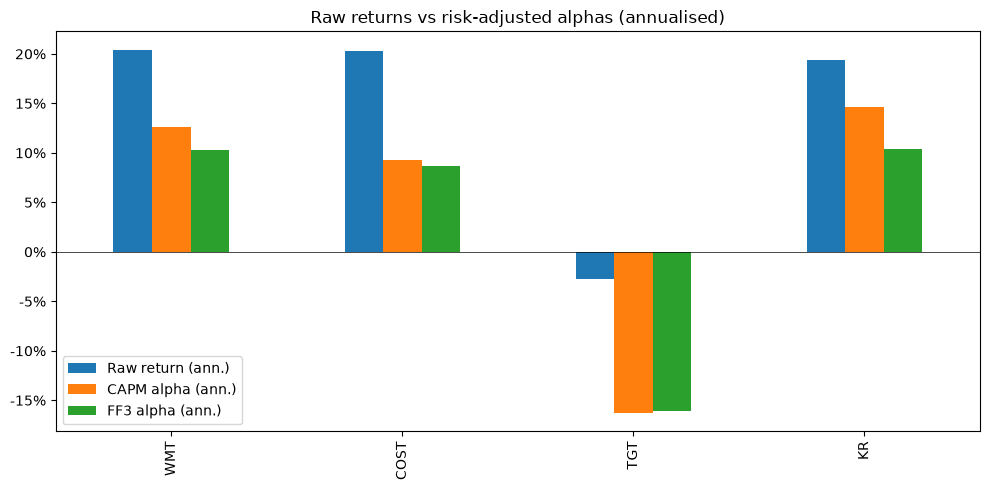

In [36]:
comparison = pd.DataFrame({
    "Raw return (ann.)": summary.loc[tickers, "Annualised return"],
    "CAPM alpha (ann.)": capm_table["Alpha (annualised)"],
    "CAPM t-stat": capm_table["Alpha t-stat"],
    "FF3 alpha (ann.)": ff3_table["Alpha (annualised)"],
    "FF3 t-stat": ff3_table["Alpha t-stat"],
})
print(comparison.round(4))
comparison.round(4).to_csv("comparison_table.csv")

comparison[["Raw return (ann.)", "CAPM alpha (ann.)", "FF3 alpha (ann.)"]].plot(
    kind="bar", figsize=(10, 5), title="Raw returns vs risk-adjusted alphas (annualised)")
plt.axhline(0, color="black", linewidth=0.5)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("fig4_raw_vs_alpha.png", dpi=200)
plt.show()